In [9]:
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

PROJECT_ROOT = Path.cwd().parent

X_train = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "X_train.csv"
)

X_test = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "X_test.csv"
)

y_train = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "y_train.csv"
).squeeze()

y_test = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "y_test.csv"
).squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nColumns:")
print(X_train.columns.tolist())

X_train shape: (492, 12)
X_test shape: (123, 12)

Columns:
['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT', 'Sex_m']


In [10]:
feature_sets = {
    "All Features": [
        'Age', 'ALB', 'ALP', 'ALT', 'AST',
        'BIL', 'CHE', 'CHOL', 'CREA',
        'GGT', 'PROT', 'Sex_m'
    ],

    "Top 8": [
        'AST', 'ALB', 'BIL', 'CHE',
        'ALP', 'GGT', 'PROT', 'ALT',
        'Sex_m'
    ],

    "Top 6": [
        'AST', 'ALB', 'BIL', 'CHE',
        'ALP', 'GGT',
        'Sex_m'
    ],

    "Top 4": [
        'AST', 'ALB', 'BIL', 'CHE',
        'Sex_m'
    ]
}

for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")
    print(features)
    print()

All Features: 12 features
['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT', 'Sex_m']

Top 8: 9 features
['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT', 'PROT', 'ALT', 'Sex_m']

Top 6: 7 features
['AST', 'ALB', 'BIL', 'CHE', 'ALP', 'GGT', 'Sex_m']

Top 4: 5 features
['AST', 'ALB', 'BIL', 'CHE', 'Sex_m']



In [11]:
results = []

for name, features in feature_sets.items():

    # Select the current feature subset
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    # Create and train model
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_subset, y_train)

    # Predictions
    y_pred = model.predict(X_test_subset)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Feature Set": name,
        "Number of Features": len(features),
        "Accuracy": accuracy,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Feature Set,Number of Features,Accuracy,F1 Score
0,All Features,12,0.934959,0.934631
1,Top 8,9,0.943089,0.940970
2,Top 6,7,0.934959,0.933201
3,Top 4,5,0.869919,0.890453


In [12]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    results_dir / "feature_subset_validation.csv",
    index=False
)

print(
    "Saved:",
    results_dir / "feature_subset_validation.csv"
)

Saved: c:\Users\sofiy\OneDrive\Desktop\Quantara-1\results\feature_subset_validation.csv


In [13]:
best_result = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best feature subset based on weighted F1:")
print(best_result)

Best feature subset based on weighted F1:
Feature Set              Top 8
Number of Features           9
Accuracy              0.943089
F1 Score               0.94097
Name: 1, dtype: object


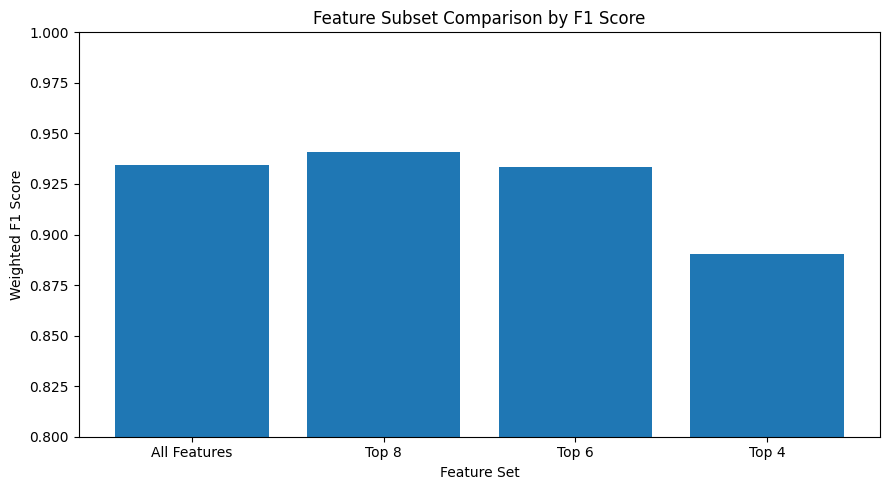

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Feature Set"],
    results_df["F1 Score"]
)

plt.title("Feature Subset Comparison by F1 Score")
plt.xlabel("Feature Set")
plt.ylabel("Weighted F1 Score")

plt.ylim(0.80, 1.0)

plt.tight_layout()
plt.show()

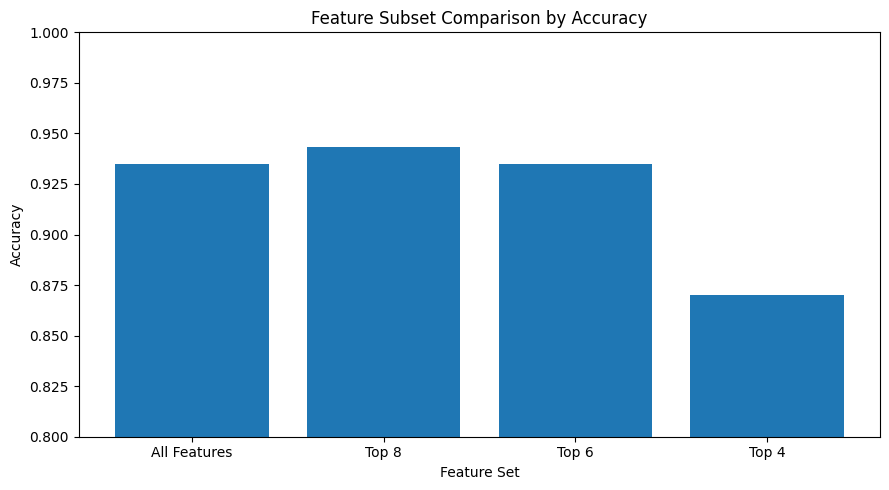

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Feature Set"],
    results_df["Accuracy"]
)

plt.title("Feature Subset Comparison by Accuracy")
plt.xlabel("Feature Set")
plt.ylabel("Accuracy")

plt.ylim(0.80, 1.0)

plt.tight_layout()
plt.show()

In [16]:
best_result = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("FEATURE SUBSET VALIDATION CONCLUSION")
print("-" * 45)

print(f"Best subset: {best_result['Feature Set']}")
print(f"Number of features: {best_result['Number of Features']}")
print(f"Accuracy: {best_result['Accuracy']:.4f}")
print(f"Weighted F1 Score: {best_result['F1 Score']:.4f}")

print("\nConclusion:")
print(
    "The Top 8 feature subset achieved the best performance "
    "in the initial Random Forest validation while using fewer "
    "features than the complete dataset."
)
print(
    "Therefore, Top 8 is selected as the primary candidate "
    "feature subset for further QML experiments."
)

FEATURE SUBSET VALIDATION CONCLUSION
---------------------------------------------
Best subset: Top 8
Number of features: 9
Accuracy: 0.9431
Weighted F1 Score: 0.9410

Conclusion:
The Top 8 feature subset achieved the best performance in the initial Random Forest validation while using fewer features than the complete dataset.
Therefore, Top 8 is selected as the primary candidate feature subset for further QML experiments.
